In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("clean_customer_churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.shape)

(7043, 21)


In [5]:
print(df.shape)

(7043, 21)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
print("Mean Monthly Charges:", df["MonthlyCharges"].mean())

Mean Monthly Charges: 64.76169246059918


In [9]:
print("Median Monthly Charges:", df["MonthlyCharges"].median())

Median Monthly Charges: 70.35


In [10]:
print("Standard Deviation:", df["MonthlyCharges"].std())

Standard Deviation: 30.09004709767854


In [11]:
churn_yes = df[df["Churn"]=="Yes"]["MonthlyCharges"]

churn_no = df[df["Churn"]=="No"]["MonthlyCharges"]

In [12]:
t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("T-Statistic :", t_stat)

print("P-Value :", p_value)

T-Statistic : 16.536738015936308
P-Value : 2.7066456068884154e-60


In [13]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Monthly Charges significantly affect Customer Churn.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference found.")

Reject Null Hypothesis
Monthly Charges significantly affect Customer Churn.


In [14]:
table = pd.crosstab(df["Contract"], df["Churn"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi Square :", chi2)

print("P Value :", p)

Chi Square : 1184.5965720837926
P Value : 5.863038300673391e-258


In [15]:
if p < 0.05:
    print("Contract Type and Churn are associated.")
else:
    print("No significant association.")

Contract Type and Churn are associated.


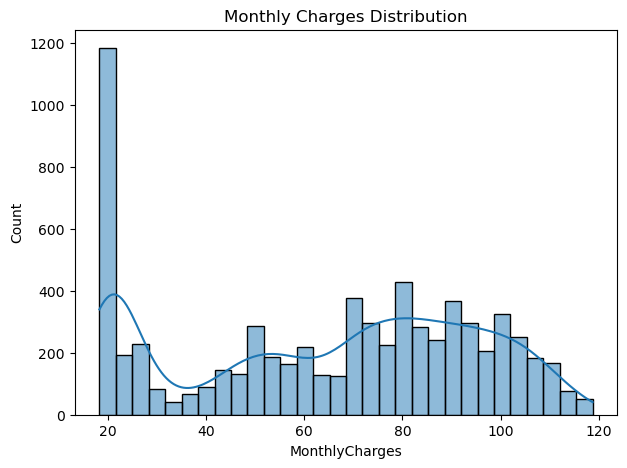

In [16]:
plt.figure(figsize=(7,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

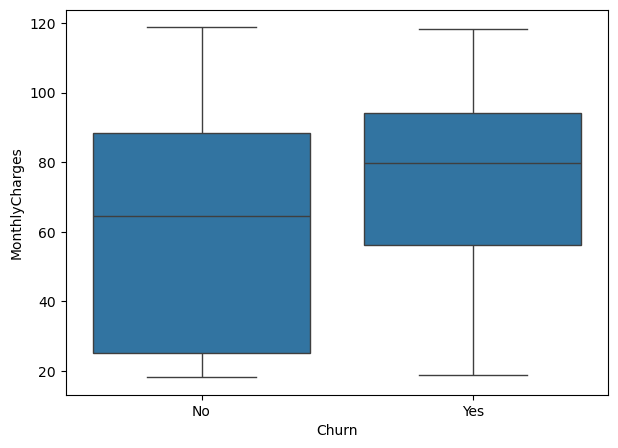

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.show()

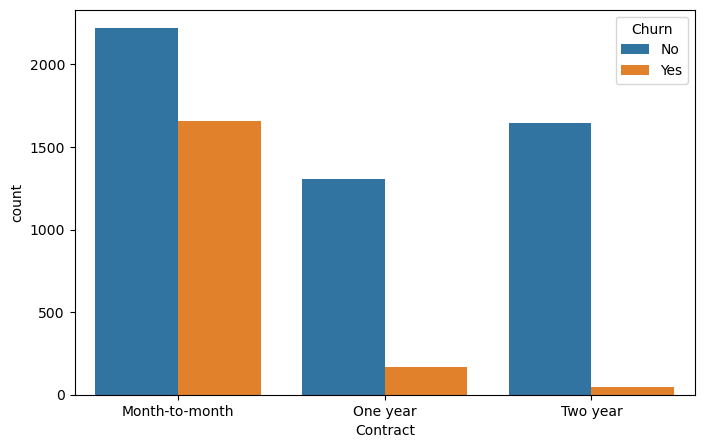

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.show()

In [19]:
print("="*60)

print("BUSINESS HYPOTHESIS")

print("="*60)

print("H0 : Monthly Charges do not affect Customer Churn.")

print("H1 : Monthly Charges significantly affect Customer Churn.")

BUSINESS HYPOTHESIS
H0 : Monthly Charges do not affect Customer Churn.
H1 : Monthly Charges significantly affect Customer Churn.


In [20]:
print("="*60)

print("BUSINESS RECOMMENDATIONS")

print("="*60)

print("1. Reduce churn by offering better pricing plans.")

print("2. Encourage long-term contracts.")

print("3. Target high monthly charge customers with retention offers.")

print("4. Monitor customers likely to churn.")

print("5. Use statistical evidence before making pricing decisions.")

BUSINESS RECOMMENDATIONS
1. Reduce churn by offering better pricing plans.
2. Encourage long-term contracts.
3. Target high monthly charge customers with retention offers.
4. Monitor customers likely to churn.
5. Use statistical evidence before making pricing decisions.


In [21]:
print("="*60)

print("PROJECT CONCLUSION")

print("="*60)

print("""
Statistical analysis was performed on the customer churn dataset.

A T-Test and Chi-Square Test were used to validate business hypotheses.

The results help businesses make data-driven decisions instead of relying on assumptions.

Statistical testing improves confidence in business strategies and customer retention planning.
""")

PROJECT CONCLUSION

Statistical analysis was performed on the customer churn dataset.

A T-Test and Chi-Square Test were used to validate business hypotheses.

The results help businesses make data-driven decisions instead of relying on assumptions.

Statistical testing improves confidence in business strategies and customer retention planning.

